In [19]:
#Spectrum plots from csv data
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
from si_prefix import si_format
# Load transient data from CSV files
csv_path = 'C:/Users/adant/Documents/interpolated_signals.csv'
df = pd.read_csv(csv_path)
time = df['time'].values
voltage = df['voltage_ss'].values
#voltage_ff = df['voltage_ff'].values
#voltage_tt = df['voltage_tt'].values
#voltage_ss = df['voltage_ss'].values

In [14]:
# Generate a local version of simple_eye to modify it for our specific use case, if needed.
def simple_eye(voltage, samples_per_symbol, ntraces, t_d, signal_offset=0, res=600, linewidth=0.15):
    """Generates simple eye diagram

    Parameters
    ----------
    voltage: array
        signal to be plotted
    
    samples_per_symbol: int
        number of time steps in eye diagram x axis
    
    ntraces: int
        number of traces to be plotted
    
    t_d: float
        timestep of time domain signal
    
    signal_offset: int, optional
        number of samples to shift the signal for better eye opening visualization
        
    res: int, optional
        DPI resolution of the figure
        
    linewidth: float, optional
        width of lines in figure
    """

    signal_crop = voltage[signal_offset:signal_offset+ntraces*samples_per_symbol]
    traces = np.split(signal_crop,ntraces)

    t = np.linspace(-(t_d*(samples_per_symbol-1))/2,(t_d*(samples_per_symbol-1))/2, samples_per_symbol)
    
    plt.figure(figsize=(4, 3))
    for i in range(ntraces):
        plt.plot(t*1e12,np.reshape((traces[i][:]),samples_per_symbol), color = 'green', linewidth = linewidth)
        #plt.plot(t*1e12,np.reshape((traces[i][:]),samples_per_symbol), linewidth = linewidth)
        #plt.plot(t*1e12,np.reshape((traces[i][:]),samples_per_symbol), color = 'green', alpha=0.01, linewidth = linewidth)
    #plt.title(title)
    plt.xlabel('Time (ps)', fontweight='bold')
    plt.ylabel('Differential Voltage (V)', fontweight='bold')
    plt.xlim(0.5*samples_per_symbol*t_d*1e12, -0.5*samples_per_symbol*t_d*1e12)
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig('simple_eye_diagram.pdf', dpi=res)
    plt.savefig('simple_eye_diagram.png', dpi=res)
    plt.show()
    return True


def eye_zero_crossing_histogram(voltage, samples_per_symbol, ntraces, t_d, signal_offset=0, title='Eye trace zero-crossing histogram', bins=100, res=600, color='navy'):
    """Extracts eye traces like simple_eye and plots histograms of first and last zero-crossing times."""

    signal_crop = voltage[signal_offset:signal_offset + ntraces * samples_per_symbol]
    traces = np.reshape(signal_crop, (ntraces, samples_per_symbol))
    t = np.linspace(-(t_d * (samples_per_symbol - 1)) / 2, (t_d * (samples_per_symbol - 1)) / 2, samples_per_symbol) * 1e12

    zero_times_first = []
    zero_times_last = []
    for trace in traces:
        crossing_idx = np.where(np.diff(np.sign(trace)) != 0)[0]
        if len(crossing_idx) > 0:
            # First crossing
            idx = crossing_idx[0]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t[idx]
                x1 = t[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_first.append(x_zero)
            
            # Last crossing
            idx = crossing_idx[-1]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t[idx]
                x1 = t[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_last.append(x_zero)

    zero_times_first = np.array(zero_times_first)
    zero_times_last = np.array(zero_times_last)

    # Plot histogram for first zero crossings
    plt.figure(figsize=(6, 4))
    plt.hist(zero_times_first, bins=bins, color=color, alpha=0.75)
    plt.title('First Zero Crossing Histogram')
    plt.xlabel('Zero crossing time [ps]', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot histogram for last zero crossings
    plt.figure(figsize=(6, 4))
    plt.hist(zero_times_last, bins=bins, color=color, alpha=0.75)
    plt.title('Last Zero Crossing Histogram')
    plt.xlabel('Zero crossing time [ps]', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return zero_times_first, zero_times_last


def eye_diagram_with_zero_crossing_histogram(voltage, samples_per_symbol, ntraces, t_d, signal_offset=0, bins=100, res=600):
    """Combines eye diagram and zero-crossing histogram in side-by-side subplots for first and last crossings."""

    signal_crop = voltage[signal_offset:signal_offset + ntraces * samples_per_symbol]
    traces = np.reshape(signal_crop, (ntraces, samples_per_symbol))
    t = np.linspace(-(t_d * (samples_per_symbol - 1)) / 2, (t_d * (samples_per_symbol - 1)) / 2, samples_per_symbol)
    t_ps = t * 1e12

    zero_times_first = []
    zero_times_last = []
    for trace in traces:
        crossing_idx = np.where(np.diff(np.sign(trace)) != 0)[0]
        if len(crossing_idx) > 0:
            # First crossing
            idx = crossing_idx[0]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t_ps[idx]
                x1 = t_ps[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_first.append(x_zero)
            
            # Last crossing
            idx = crossing_idx[-1]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t_ps[idx]
                x1 = t_ps[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_last.append(x_zero)

    zero_times_first = np.array(zero_times_first)
    zero_times_last = np.array(zero_times_last)

    #zero crossing mean and std dev
    print(f"First zero crossing: Mean = {np.mean(zero_times_first):.4f} ps, Std Dev = {np.std(zero_times_first):.4f} ps")
    print(f"Last zero crossing: Mean = {np.mean(zero_times_last):.4f} ps, Std Dev = {np.std(zero_times_last):.4f} ps")

    #Eye diagram limits based on zero crossing times
    eye_xlim_first = (min(zero_times_first) - 10, max(zero_times_first) + 10)
    eye_xlim_last = (min(zero_times_last) - 10, max(zero_times_last) + 10)


    # Figure 1: Eye diagram and histogram for first zero crossings
    fig1, (ax1_eye, ax1_hist) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot eye diagram on top
    for i in range(ntraces):
        ax1_eye.plot(t_ps, traces[i, :], color='green', linewidth=0.15)
    ax1_eye.set_xlabel('Time (ps)', fontweight='bold')
    ax1_eye.set_ylabel('Differential Voltage (V)', fontweight='bold')
    ax1_eye.set_xlim(eye_xlim_first[0], eye_xlim_first[1])
    ax1_eye.grid(True)
    ax1_eye.set_title('Eye Diagram (First Zero Crossing)', fontweight='bold')
    
    # Plot histogram on bottom
    ax1_hist.hist(zero_times_first, bins=bins, color='navy', alpha=0.75)
    ax1_hist.set_xlabel('Zero crossing time [ps]', fontweight='bold')
    ax1_hist.set_ylabel('Count', fontweight='bold')
    ax1_hist.set_xlim(eye_xlim_first[0], eye_xlim_first[1])
    ax1_hist.grid(True, alpha=0.3)
    ax1_hist.set_title('First Zero Crossing Histogram', fontweight='bold')
    
    fig1.tight_layout()
    fig1.savefig('eye_diagram_first_crossing.pdf', dpi=res)
    plt.show()

    # Figure 2: Eye diagram and histogram for last zero crossings
    fig2, (ax2_eye, ax2_hist) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot eye diagram on top
    for i in range(ntraces):
        ax2_eye.plot(t_ps, traces[i, :], color='green', linewidth=0.15)
    ax2_eye.set_xlabel('Time (ps)', fontweight='bold')
    ax2_eye.set_ylabel('Differential Voltage (V)', fontweight='bold')
    ax2_eye.set_xlim(eye_xlim_last[0], eye_xlim_last[1])
    ax2_eye.grid(True)
    ax2_eye.set_title('Eye Diagram (Last Zero Crossing)', fontweight='bold')
    
    # Plot histogram on bottom
    ax2_hist.hist(zero_times_last, bins=bins, color='navy', alpha=0.75)
    ax2_hist.set_xlabel('Zero crossing time [ps]', fontweight='bold')
    ax2_hist.set_ylabel('Count', fontweight='bold')
    ax2_hist.set_xlim(eye_xlim_last[0], eye_xlim_last[1])
    ax2_hist.grid(True, alpha=0.3)
    ax2_hist.set_title('Last Zero Crossing Histogram', fontweight='bold')
    
    fig2.tight_layout()
    fig2.savefig('eye_diagram_last_crossing.pdf', dpi=res)
    plt.show()

    return zero_times_first, zero_times_last


def eye_diagram_with_inset_histogram(voltage, samples_per_symbol, ntraces, t_d, signal_offset=0, bins=100, res=600):
    """Combines eye diagram with inset histogram above it for first and last crossings."""

    signal_crop = voltage[signal_offset:signal_offset + ntraces * samples_per_symbol]
    traces = np.reshape(signal_crop, (ntraces, samples_per_symbol))
    t = np.linspace(-(t_d * (samples_per_symbol - 1)) / 2, (t_d * (samples_per_symbol - 1)) / 2, samples_per_symbol)
    t_ps = t * 1e12

    zero_times_first = []
    zero_times_last = []
    for trace in traces:
        crossing_idx = np.where(np.diff(np.sign(trace)) != 0)[0]
        if len(crossing_idx) > 0:
            # First crossing
            idx = crossing_idx[0]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t_ps[idx]
                x1 = t_ps[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_first.append(x_zero)
            
            # Last crossing
            idx = crossing_idx[-1]
            y0 = trace[idx]
            y1 = trace[idx + 1]
            if y1 != y0:
                x0 = t_ps[idx]
                x1 = t_ps[idx + 1]
                x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
                zero_times_last.append(x_zero)

    zero_times_first = np.array(zero_times_first)
    zero_times_last = np.array(zero_times_last)

    #zero crossing mean and std dev
    print(f"First zero crossing: Mean = {np.mean(zero_times_first):.4f} ps, Std Dev = {np.std(zero_times_first):.4f} ps")
    print(f"Last zero crossing: Mean = {np.mean(zero_times_last):.4f} ps, Std Dev = {np.std(zero_times_last):.4f} ps")

    #Eye diagram limits based on zero crossing times
    eye_xlim_first = (min(zero_times_first) - 10, max(zero_times_first) + 10)
    eye_xlim_last = (min(zero_times_last) - 10, max(zero_times_last) + 10)

    # Figure 1: Eye diagram with inset histogram for first zero crossings
    fig1, ax1 = plt.subplots(figsize=(4, 3))
    
    # Plot eye diagram
    for i in range(ntraces):
        ax1.plot(t_ps, traces[i, :], color='green', linewidth=0.15)
    ax1.set_xlabel('Time (ps)', fontweight='bold')
    ax1.set_ylabel('Differential Voltage (V)', fontweight='bold')
    ax1.set_xlim(eye_xlim_first[0], eye_xlim_first[1])
    ax1.grid(True)
    #ax1.set_title('Eye Diagram with Inset Histogram (First Zero Crossing)', fontweight='bold')
    
    # Inset histogram above the eye diagram
    ax1_inset = ax1.inset_axes([0, 0, 1, 0.5])  # [x, y, width, height] in figure coordinates
    ax1_inset.set_facecolor('none')  # Make background transparent
    ax1_inset.hist(zero_times_first, bins=bins, color='navy', alpha=0.5)  # Reduce alpha for transparency
    ax1_inset.set_xlim(eye_xlim_first[0], eye_xlim_first[1])
    ax1_inset.set_xticks([])
    ax1_inset.set_yticks([])
    #ax1_inset.set_title('First Zero Crossing Histogram', fontsize=10, fontweight='bold')
    
    fig1.tight_layout()
    #fig1.savefig('eye_diagram_inset_first_crossing.pdf', dpi=res)
    fig1.savefig('eye_diagram_inset_first_crossing.png', dpi=res)
    plt.show()

    # Figure 2: Eye diagram with inset histogram for last zero crossings
    fig2, ax2 = plt.subplots(figsize=(4, 3))
    
    # Plot eye diagram
    for i in range(ntraces):
        ax2.plot(t_ps, traces[i, :], color='green', linewidth=0.15)
    ax2.set_xlabel('Time (ps)', fontweight='bold')
    ax2.set_ylabel('Differential Voltage (V)', fontweight='bold')
    ax2.set_xlim(eye_xlim_last[0], eye_xlim_last[1])
    ax2.grid(True)
    #ax2.set_title('Eye Diagram with Inset Histogram (Last Zero Crossing)', fontweight='bold')
    
    # Inset histogram above the eye diagram
    ax2_inset = ax2.inset_axes([0, 0, 1, 0.5])  # [x, y, width, height] in figure coordinates
    ax2_inset.set_facecolor('none')  # Make background transparent
    ax2_inset.hist(zero_times_last, bins=bins, color='navy', alpha=0.5)  # Reduce alpha for transparency
    ax2_inset.set_xlim(eye_xlim_last[0], eye_xlim_last[1])
    ax2_inset.set_xticks([])
    ax2_inset.set_yticks([])
    #ax2_inset.set_title('Last Zero Crossing Histogram', fontsize=10, fontweight='bold')
    
    fig2.tight_layout()
    #fig2.savefig('eye_diagram_inset_last_crossing.pdf')
    fig2.savefig('eye_diagram_inset_last_crossing.png', dpi=res)
    plt.show()

    return zero_times_first, zero_times_last

Number of traces to plot: 60000
Number of available traces to plot: 65000


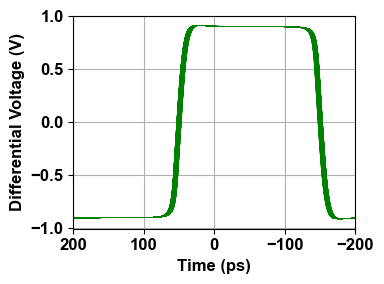

First zero crossing: Mean = -150.4390 ps, Std Dev = 0.8855 ps
Last zero crossing: Mean = 50.2509 ps, Std Dev = 0.8843 ps


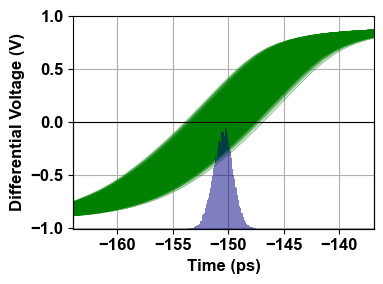

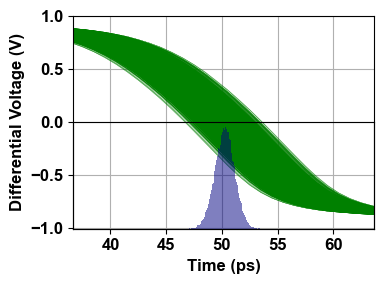

Generated eye diagram with inset histogram plots.


In [20]:

datarate = 5e9
data_period = 1/datarate
fosc = 2.5e9  # Oscillation frequency of the PLL in Hz
# Step time
t_d=1e-12    
# Bit period
samples_per_symbol = round(data_period/t_d)
signal_offset= 18

# Find the number of traces to plot for the eye diagram, ensuring it does not exceed the available data
# round down the number of traces to ensure we have enough data points for each trace      
max_traces = round(len(time) / (samples_per_symbol * 2))  # Each eye diagram trace will consist of 2 symbols (2 * samples_per_symbol)
ntraces = min(60000, max_traces)  # Limit to 60000 traces for better visualization, but ensure it does not exceed the maximum possible based on the data length
print(f"Number of traces to plot: {ntraces}")
print(f"Number of available traces to plot: {max_traces}")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'


# Call the simple_eye function to generate the eye diagram for the Fast-Fast (FF) signal
simple_eye(voltage, samples_per_symbol*2, ntraces, t_d, signal_offset, res=600, linewidth=0.15)

# Generate and plot the zero-crossing histogram from each eye trace
#first_crossings, last_crossings = eye_zero_crossing_histogram(voltage, samples_per_symbol*2, ntraces, t_d, signal_offset, title='Zero crossing histogram', bins=100, res=600, color='navy')
#print(f'Found {len(first_crossings)} first zero crossings and {len(last_crossings)} last zero crossings across {ntraces} traces.')

# Generate combined eye diagram and histogram figures
#first_combined, last_combined = eye_diagram_with_zero_crossing_histogram(voltage, samples_per_symbol*2, ntraces, t_d, signal_offset, bins=100, res=600)
#print(f'Generated combined eye diagram and histogram plots.')

# Generate eye diagram with inset histogram
first_inset, last_inset = eye_diagram_with_inset_histogram(voltage, samples_per_symbol*2, ntraces, t_d, signal_offset, bins=100, res=600)
print(f'Generated eye diagram with inset histogram plots.')

